# 01. Data preprocessing — переиспользуемый слой

Собираем все договорённости проекта по предобработке запросов и реализуем их в `src.preprocessing`, чтобы другие ноутбуки импортировали **один** пайплайн.

Полный список гипотез: [`README.md`](./README.md).

> Фокус ноутбука — только preprocess (+ построение словарей MODEL / protected brands).  
> Обучение CRF/классификаторов здесь не делаем.


## 0. Setup


In [1]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter

ROOT = Path.cwd().resolve()
if ROOT.name in {"preprocessing", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "preprocessing" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks, ARTIFACTS_DIR, FIGURES_DIR,
    MVIDEO_RED, DARK_SLATE, save_stats,
)
from src.ner.labeling import WeakLabeler, bio_to_entities
from src.preprocessing import (
    QueryPreprocessor,
    build_model_lexicon_from_titles,
    save_phrase_list,
    load_phrase_list,
    split_glued_alnum,
)
from src.preprocessing.pipeline import MODEL_SEEDS, PROTECTED_BRAND_SEEDS, basic_clean

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "preprocessing"
FIG.mkdir(parents=True, exist_ok=True)
ART = ARTIFACTS_DIR
ART.mkdir(exist_ok=True)

def save_local(fig, name):
    p = FIG / name
    fig.savefig(p, dpi=160, bbox_inches="tight", facecolor="white")
    print("saved", p)
    return p

SAMPLE_N = 150_000
print("ROOT:", ROOT)


d:\Projects-26-06-2026\mvideo-ner-search\.venv\Lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ROOT: D:\Projects-26-06-2026\mvideo-ner-search


## 1. Гипотезы (кратко)

| ID | Гипотеза | Что делаем в preprocess |
|---|---|---|
| H1 | Грязный ввод (`128гб`, `g-pro`) | split units, нормализация сепараторов |
| H2 | Регистр важен («Красный Октябрь») | не слепой lower; protected brands; Title Case hints |
| H3 | Хвосты `g pro x se` = MODEL | lexicon сиды + майнинг из `sku_name` |
| H4 | ATTR-regex не ловит линейки | не пытаемся «допилить regex»; отдельный MODEL |
| H5 | Бренд часто вне текста | **не** чинится preprocess → clf/клики |
| H6 | ё/×/NBSP | унификация |

Слабые места — в конце ноутбука.


*мысли*

Мы видим, что хвосты не попадают как модель, её просто нет в словарях, надо подумать как разметить так, чтобы модельке было ясно, где начинается тег `B-MODEL`/`I-MODEL`.

По большей части это решается ещё одной silver-разметкой, делаем дополнение в `labeling.py` и радуемся жизни, верно? Мне неясно, что имеется в виду под майнингом, вероятно что-то вроде обычного парсинга?

## 2. Демо шагов на жёстких примерах


In [2]:
examples = [
    "наушники logitech g-pro x se",
    "Ноутбук ASUS 16гб",
    "Красный Октябрь конфеты",
    "пылесос dyson v15",
    "iphone 15 pro max 256gb",
    "телевизор 55дюйм samsung",
]

rows = []
for q in examples:
    cleaned = basic_clean(q)
    rows.append({
        "original": q,
        "basic_clean": cleaned,
        "split_only": split_glued_alnum(q),
        "text_norm": QueryPreprocessor()(q).text_norm,
    })
pd.DataFrame(rows)


,original,basic_clean,split_only,text_norm
0,наушники logitech g-pro x se,наушники logitech g pro x se,наушники logitech g-pro x se,наушники logitech g pro x se
1,Ноутбук ASUS 16гб,Ноутбук ASUS 16 гб,Ноутбук ASUS 16 гб,ноутбук asus 16 гб
2,Красный Октябрь конфеты,Красный Октябрь конфеты,Красный Октябрь конфеты,красный октябрь конфеты
3,пылесос dyson v15,пылесос dyson v15,пылесос dyson v15,пылесос dyson v15
4,iphone 15 pro max 256gb,iphone 15 pro max 256 gb,iphone 15 pro max 256 gb,iphone 15 pro max 256 gb
5,телевизор 55дюйм samsung,телевизор 55 дюйм samsung,телевизор 55 дюйм samsung,телевизор 55 дюйм samsung


## 3. Майнинг MODEL-фраз из кликнутых SKU + сиды

Строим `artifacts/model_phrases.txt`: сиды (`g pro`, `v15`, …) ∪ частые хвосты после бренда в `sku_name`.


mined phrases (≥4): 7906
wrote D:\Projects-26-06-2026\mvideo-ner-search\artifacts\model_phrases.txt n= 6130
wrote D:\Projects-26-06-2026\mvideo-ner-search\artifacts\protected_brands.txt


,phrase,count
0,iphone,4688
1,galaxy,4626
2,iphone 17,2047
3,watch,1652
4,iphone 17 pro max,1644
5,iphone 17 pro,1466
6,redmi,1202
7,iphone 17 pro 256,972
8,galaxy s25,965
9,iphone 17 256 gb,942


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\preprocessing\01_mined_model_phrases.png


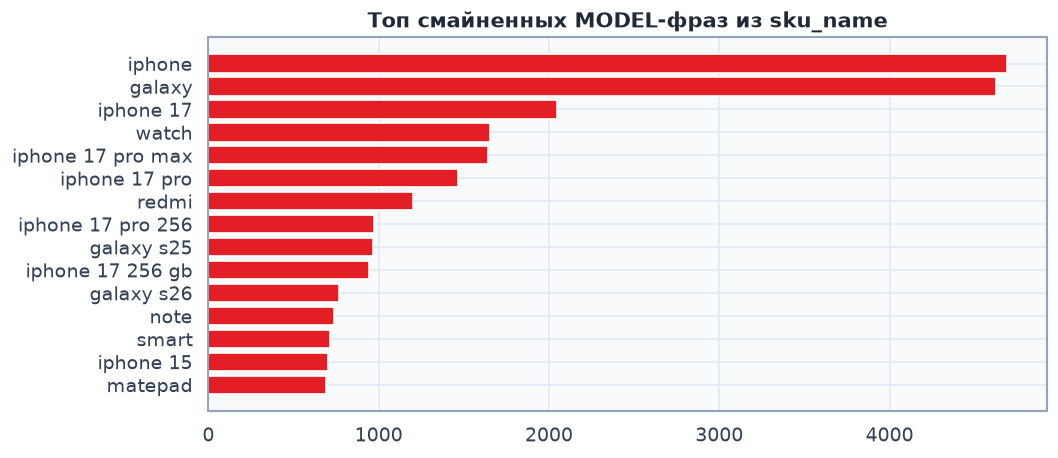

In [3]:
clicks = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
brands = (
    clicks["sku_brand_name"].astype(str).str.strip().replace("", np.nan).dropna().value_counts().head(400).index.tolist()
)
titles = clicks["sku_name"].astype(str).dropna().tolist()

mined = build_model_lexicon_from_titles(titles, brands, min_count=4, max_phrase_tokens=4)
print(f"mined phrases (≥4): {len(mined)}")

# объединяем с сидами
all_models = set(MODEL_SEEDS) | set(mined)
# немного ручного приоритета: оставляем фразы, где есть digit или известный префикс
def keep(p: str) -> bool:
    if p in MODEL_SEEDS:
        return True
    toks = p.split()
    if any(ch.isdigit() for ch in p):
        return True
    if toks and toks[0] in {"g", "v", "ps", "air", "galaxy", "redmi", "poco", "iphone", "macbook"}:
        return len(toks) >= 2
    return len(toks) >= 2 and mined.get(p, 0) >= 10

filtered = {p for p in all_models if keep(p)}
path_models = save_phrase_list(filtered, ART / "model_phrases.txt")
path_prot = save_phrase_list(PROTECTED_BRAND_SEEDS | set(load_phrase_list(ART / "protected_brands.txt")), ART / "protected_brands.txt")
print("wrote", path_models, "n=", len(filtered))
print("wrote", path_prot)

top_mined = pd.DataFrame(sorted(mined.items(), key=lambda x: -x[1])[:25], columns=["phrase", "count"])
display(top_mined)

fig, ax = plt.subplots(figsize=(9, 4))
show = top_mined.head(15)
ax.barh(show["phrase"][::-1], show["count"][::-1], color=MVIDEO_RED)
ax.set_title("Топ смайненных MODEL-фраз из sku_name")
fig.tight_layout()
save_local(fig, "01_mined_model_phrases.png")
plt.show()


## 4. QueryPreprocessor: MODEL + protected brand на запросах


In [10]:
pp = QueryPreprocessor.from_artifacts(ART)
labeler = WeakLabeler.from_files(ART / "brands.txt", ART / "categories.txt")

demo_queries = [
    "наушники logitech g pro x se",
    "наушники logitech g-pro x se",
    "Красный Октябрь",
    "красный телефон",
    "dyson v15 detect",
    "samsung galaxy s24 ultra",
    "самсунг 16 про",
    "наушники logitech g-pro x se",
    "Ноутбук ASUS 16гб",
    "Красный Октябрь конфеты",
    "пылесос dyson v15",
    "iphone 15 pro max 256gb",
    "телевизор 55дюйм samsung",
    "asus tuf gaming a15"
]

demo_rows = []
for q in demo_queries:
    r = pp(q)
    weak = labeler.label_query(r.text_norm)
    merged = pp.merge_bio_hints(weak, r)
    demo_rows.append({
        "query": q,
        "text_norm": r.text_norm,
        "model_spans": r.model_spans,
        "protected": r.protected_spans,
        "titlecase": r.titlecase_hints,
        "bio_weak": weak,
        "bio_merged": merged,
    })

pd.DataFrame([{k: demo_rows[i][k] for k in ["query", "text_norm", "model_spans", "protected", "bio_merged"]} for i in range(len(demo_rows))])["bio_merged"].iloc[-1]


[('asus', 'B-BRAND'), ('tuf', 'O'), ('gaming', 'O'), ('a15', 'O')]

*мысли*

По-прежнему разметка не самая лучшая, вот недочёты которые я вижу:
- silver-разметка типа regex по `16 про` - зачастую не работает, т.к. некоторые случаи могут её обходить/не входить в правила
- Проблема с опечатками, например "O" == "самунг" != "самсунг" == "B-BRAND".
- У нас до сих пор нет классификации, на пример: `16 гб` -> `память`, но это естественно, т.к. пока что это чисто BIO разметка

## 5. Метрика эффекта на семпле уникальных запросов

Считаем, как часто появляется `MODEL` после preprocess+merge, и как часто хвост после бренда перестаёт быть полностью `O`.


,metric,value
0,n_queries,12000.000000
1,share_model_span,0.179250
2,share_protected_or_titlecase,0.044500
3,share_glued_unit_fixable,0.107917
4,n_brand_tail_all_O,2975.000000
5,n_tail_improved_with_MODEL,727.000000
6,tail_improve_rate,0.244370
7,n_model_phrases_dict,6130.000000


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\preprocessing\02_preprocess_effect.png


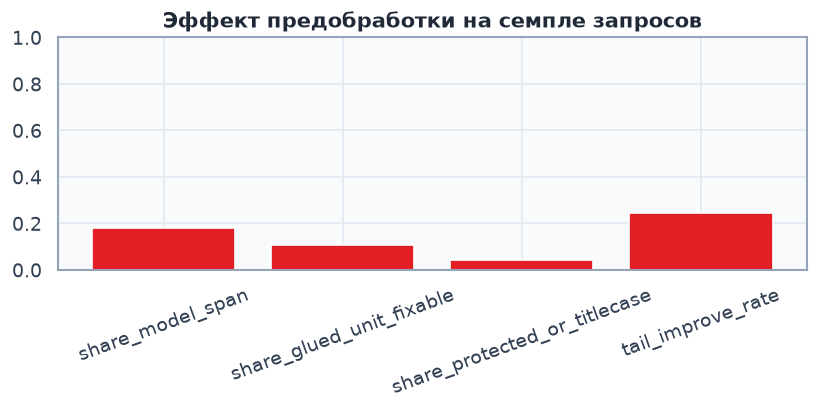

In [5]:
uq = clicks["query_text"].astype(str).str.strip()
uq = uq[uq.str.len() >= 2].drop_duplicates()
sample_q = uq.sample(n=min(12_000, len(uq)), random_state=42).tolist()

n_model = 0
n_protected = 0
n_glued_fixed = 0
n_tail_o_before = 0
n_tail_improved = 0

def has_all_o_tail_after_brand(tags):
    idxs = [i for i, (_, t) in enumerate(tags) if "BRAND" in t]
    if not idxs:
        return False
    last = max(idxs)
    tail = tags[last + 1:]
    return bool(tail) and all(t == "O" for _, t in tail)

for q in sample_q:
    if split_glued_alnum(q) != q:
        n_glued_fixed += 1
    r = pp(q)
    if r.model_spans:
        n_model += 1
    if r.protected_spans or r.titlecase_hints:
        n_protected += 1
    weak = labeler.label_query(r.text_norm)
    merged = pp.merge_bio_hints(weak, r)
    before_tail = has_all_o_tail_after_brand(weak)
    after_has_model = any(t.endswith("MODEL") for _, t in merged)
    if before_tail:
        n_tail_o_before += 1
        if after_has_model:
            n_tail_improved += 1

stats = {
    "n_queries": len(sample_q),
    "share_model_span": n_model / len(sample_q),
    "share_protected_or_titlecase": n_protected / len(sample_q),
    "share_glued_unit_fixable": n_glued_fixed / len(sample_q),
    "n_brand_tail_all_O": n_tail_o_before,
    "n_tail_improved_with_MODEL": n_tail_improved,
    "tail_improve_rate": n_tail_improved / max(n_tail_o_before, 1),
    "n_model_phrases_dict": len(load_phrase_list(ART / "model_phrases.txt")),
}
display(pd.DataFrame(stats.items(), columns=["metric", "value"]))

fig, ax = plt.subplots(figsize=(7, 3.6))
keys = ["share_model_span", "share_glued_unit_fixable", "share_protected_or_titlecase", "tail_improve_rate"]
ax.bar(keys, [stats[k] for k in keys], color=MVIDEO_RED)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.set_title("Эффект предобработки на семпле запросов")
fig.tight_layout()
save_local(fig, "02_preprocess_effect.png")
plt.show()


## 6. Слабые места: что preprocess + словари НЕ закроют

### 6.1. `g pro` вне лексикона
Если завтра появится `g pro x 3e`, а фразы нет в `model_phrases.txt` и она редка в `sku_name` — останется `O`.

**Фикс не правилами:** разметить gold с тегом `MODEL` (300–1000 запросов) и учить CRF/transformer; lexicon — только bootstrap.

### 6.2. Омонимы (`pro`, `air`, `mini`)
`pro` может быть линейкой или словом. Lexicon longest-match ошибается без бренда/категории рядом.

**Фикс:** контекстный NER; не раздувать сиды однотокенным `pro` без необходимости (у нас `pro` есть в сидах — осознанный риск).

### 6.3. Бренд не написан (~74% кликов)
Preprocess не вытащит Apple из «айфон» без alias (alias — да) или из «телефон 128» без clf.

### 6.4. «красный» без «октябрь»
Title Case / protected list не сработают на lowercase «красный октябрь» — для этого фраза должна быть в `protected_brands.txt` (мы нормализуем в lower для матчинга — этот кейс **ловим**).  
А вот одиночный «красный» как бренд vs цвет — только модель/контекст.

### 6.5. Качественный датасет — когда обязателен

| Задача | Хватает preprocess+dict? | Нужен gold |
|---|---|---|
| `128гб` → токены | да | нет |
| `g-pro` → `g pro` | да | нет |
| `g pro x se` известный | да (lexicon) | желательно для обобщения |
| новая линейка / омоним | нет | **да** |
| бренд вне строки | нет | клик-лейблы / clf |
| color vs brand | частично | **да** на спорных |

Рекомендуемый формат gold (JSONL), чтобы добить хвосты:

```json
{"query": "наушники logitech g pro x se", "entities": [
  {"text": "наушники", "label": "CATEGORY"},
  {"text": "logitech", "label": "BRAND"},
  {"text": "g pro x se", "label": "MODEL"}
]}
```

Путь: `artifacts/gold/query_entities.jsonl` (создадите при разметке).


In [6]:
# Примеры, где lexicon/preprocess всё ещё слаб (для ручного просмотра)
hard = []
for q in sample_q:
    r = pp(q)
    weak = labeler.label_query(r.text_norm)
    merged = pp.merge_bio_hints(weak, r)
    # бренд есть, после него хвост из ≥2 O-токенов латиницы без MODEL
    brand_idx = [i for i, (_, t) in enumerate(merged) if t.endswith("BRAND")]
    if not brand_idx:
        continue
    last = max(brand_idx)
    tail = merged[last + 1:]
    if len(tail) >= 2 and all(t == "O" for _, t in tail):
        if all(tok.isascii() and tok.isalpha() and len(tok) <= 6 for tok, _ in tail[:4]):
            hard.append({"query": q, "tail": " ".join(t for t, _ in tail[:5]), "bio": merged})
    if len(hard) >= 15:
        break

print("Примеры хвостов, которые всё ещё O (кандидаты в gold MODEL):")
display(pd.DataFrame(hard)[["query", "tail"]] if hard else pd.DataFrame({"msg": ["мало примеров в семпле"]}))


Примеры хвостов, которые всё ещё O (кандидаты в gold MODEL):


,query,tail
0,Услуга по активации подписки PS Sony Plus Deluxe,plus deluxe
1,dji osmo nano,osmo nano
2,Rtx 5070 msi gaming trio,gaming trio
3,Philips abkmnh lkz djls,abkmnh lkz djls
4,Asus rig strix,rig strix
5,Lenovo think book,think book
6,Hisense party thu,party thu
7,samsung s pen,s pen
8,холодильник atlant no frost,no frost
9,philips one blaid,one blaid


## 7. Как использовать в других ноутбуках

```python
from src.preprocessing import QueryPreprocessor

pp = QueryPreprocessor.from_artifacts(ROOT / "artifacts")
r = pp(query)
# дальше: labeler / CRF на r.text_norm
tags = labeler.label_query(r.text_norm)
tags = pp.merge_bio_hints(tags, r)
```

Не копируйте локальные `lower()` / regex split — иначе разъедется словари `model_phrases.txt`.


In [7]:
save_stats(stats, "preprocessing_stats.json")
print("README:", ROOT / "notebooks" / "preprocessing" / "README.md")
print("Figures:", FIG)
print("Artifacts:", ART / "model_phrases.txt", ART / "protected_brands.txt")


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\preprocessing_stats.json
README: D:\Projects-26-06-2026\mvideo-ner-search\notebooks\preprocessing\README.md
Figures: D:\Projects-26-06-2026\mvideo-ner-search\figures\preprocessing
Artifacts: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\model_phrases.txt D:\Projects-26-06-2026\mvideo-ner-search\artifacts\protected_brands.txt
